## Distribución de la Energía Cinética de un Gas Ideal
---

En la teoría cinética de gases, cada componente cartesiana de la velocidad de una molécula sigue una distribución normal:
$$
v_{i\alpha} \sim N\left(0,\, v_T\right), \qquad v_T = \sqrt{\frac{k_B T}{m}}
$$
donde $\alpha \in \{x, y, z\}$, $k_B$ es la constante de Boltzmann, $T$ la temperatura y $m$ la masa de la molécula.

La energía cinética de una componente es $E_{i\alpha} = \frac{1}{2}m v_{i\alpha}^2$. Definimos la variable adimensional
$$
Y_{i\alpha} = \frac{E_{i\alpha}}{\tfrac{1}{2}k_B T} = \left(\frac{v_{i\alpha}}{v_T}\right)^2
$$
que es el cuadrado de una normal estándar, es decir $Y_{i\alpha} \sim \chi^2_1$.

La energía cinética total adimensional de $N$ moléculas en 3 dimensiones es entonces
$$
Z = \sum_{i=1}^{N} \sum_{\alpha} Y_{i\alpha} \sim \chi^2_{3N}
$$
con media $3N$ y varianza $6N$. Por el teorema del limite central, para $N$ grande $Z$ se aproxima a una normal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
# Parámetros
kB = 1.38e-23       # constante de Boltzmann (J/K)
T = 300.0     # temperatura (K)
m = 4.65e-26        # masa de N2 (kg)

# Parámetros de la simulación
n_sim = 10000      # repeticiones
n_part = 20     # número de moléculas

vT = np.sqrt(kB * T / m)        # velocidad térmica (m/s)
k = 3 * n_part     # grados de libertad totales
print(f'Velocidad térmica: vT = {vT:.1f} m/s')
print(f'Grados de libertad: k = 3N = {k}')

Velocidad térmica: vT = 298.4 m/s
Grados de libertad: k = 3N = 60


In [3]:
# Simulamos las velocidades: shape (n_sim, n_part, 3)
v = np.random.normal(scale=vT, size=(n_sim, n_part, 3))

# Variables adimensionales Y_ia = (v_ia / vT)^2  ~  chi2(1)
Y = (v / vT)**2

# Variable total Z = sum Y  ~  chi2(3N)
Z = Y.sum(axis=(1, 2))

La distribución exacta de $Z$ es $\chi^2_{3N}$, con
- $E(Z) = 3N = 60$
- $\text{Var}(Z) = 6N = 120$

Por el TLC, $Z$ se aproxima a una $N(3N,\, \sqrt{6N})$ para $N$ grande.

In [4]:
# Parámetros de las distribuciones 
mu = k       # media
sigma = np.sqrt(2 * k)  # desviación estándar

print(f'E(Z) = {Z.mean():.2f} (teórico: {mu})')
print(f'Var(Z) = {Z.var():.2f} (teórico: {2*k})')

E(Z) = 60.08 (teórico: 60)
Var(Z) = 121.24 (teórico: 120)


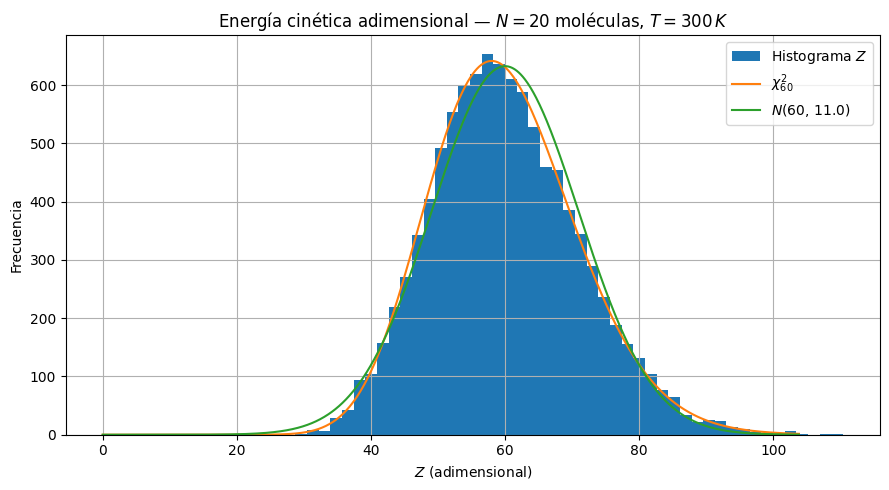

In [5]:
# Gráfico: histograma vs chi2 vs normal
x = np.linspace(0, mu + 4*sigma, 1000)

fig, ax = plt.subplots(figsize=(9, 5))
bins_out = ax.hist(Z, bins=50, label='Histograma $Z$')
width = bins_out[1][1] - bins_out[1][0]

ax.plot(x, n_sim * width * st.chi2.pdf(x, df=k),
        label=f'$\\chi^2_{{{k}}}$')
ax.plot(x, n_sim * width * st.norm.pdf(x, loc=mu, scale=sigma),
        label=f'$N({mu},\\,{sigma:.1f})$')

ax.set_title(f'Energía cinética adimensional — $N={n_part}$ moléculas, $T={T:.0f}\\,K$')
ax.set_xlabel('$Z$ (adimensional)')
ax.set_ylabel('Frecuencia')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

Vemos que los datos siguen muy bien la $\chi^2_{3N}$, y que esta ya se parece bastante a la normal para $N=20$ ($k=60$ grados de libertad), aunque no coinciden exactamente.

Para ver cómo converge el TLC al aumentar $N$, generalizamos con una función.

In [6]:
def dist_energia(n_part=20, n_sim=10000):
    """Simula la energía cinética total adimensional de n_part moléculas."""
    k  = 3 * n_part
    mu = k
    sigma = np.sqrt(2 * k)

    v = np.random.normal(size=(n_sim, n_part, 3))  # adimensional: escala=1
    Z = (v**2).sum(axis=(1, 2))

    x = np.linspace(0, mu + 5*sigma, 1000)
    fig, ax = plt.subplots(figsize=(9, 5))
    bins_out = ax.hist(Z, bins=50, label='Histograma $Z$')
    width = bins_out[1][1] - bins_out[1][0]

    ax.plot(x, n_sim * width * st.chi2.pdf(x, df=k),
            label=f'$\\chi^2_{{{k}}}$')
    ax.plot(x, n_sim * width * st.norm.pdf(x, loc=mu, scale=sigma),
            label=f'$\\mathcal{{N}}({mu},\\,{sigma:.1f})$')

    ax.set_title(f'$N={n_part}$ moléculas  ($k={k}$ grados de libertad)')
    ax.set_xlabel('$Z$ (adimensional)')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    print(f'E(Z) = {Z.mean():.2f}   (teórico: {mu})')
    print(f'Var(Z) = {Z.var():.2f}  (teórico: {2*k})')

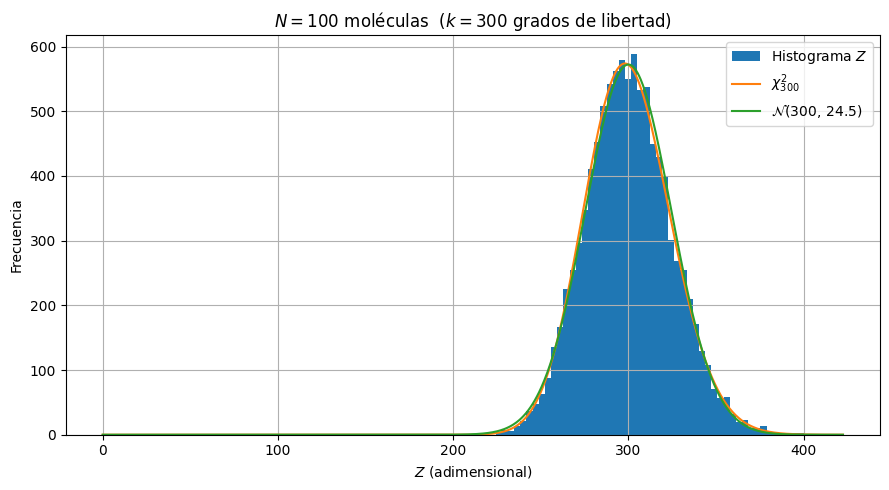

E(Z) = 300.20   (teórico: 300)
Var(Z) = 595.56  (teórico: 600)


In [7]:
# Con N=100 moléculas (k=300 grados de libertad)
dist_energia(100)

## Conclusiones

Modelamos la energía cinética total de un gas ideal de $N$ moléculas de $N_2$ a $T = 300\,\mathrm{K}$. Las componentes de velocidad $v_{i\alpha} \sim N(0, v_T)$ llevan a variables adimensionales $Y_{i\alpha} = (v_{i\alpha}/v_T)^2 \sim \chi^2_1$, y su suma
$$Z = \sum_{i,\alpha} Y_{i\alpha} \sim \chi^2_{3N}$$
reproduce exactamente la distribución chi-cuadrado con $3N$ grados de libertad — el resultado estándar de la teoría cinética.

Al aumentar $N$, la distribución converge hacia una normal con $\mu = 3N$ y $\sigma^2 = 6N$, en acuerdo con el Teorema Central del Límite. Para $N=100$ ($k=300$) la coincidencia es casi perfecta.